Import Libraries

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


Upload Dataset ZIP

In [4]:
from google.colab import files
uploaded = files.upload()

Saving archive (5).zip to archive (5) (1).zip


Extract Dataset

In [7]:
import zipfile

with zipfile.ZipFile("archive (5).zip", 'r') as zip_ref:
    zip_ref.extractall("Potato")

print("Dataset Extracted")

Dataset Extracted


Define Paths

In [8]:
train_path = "Potato/Train"
valid_path = "Potato/Valid"
test_path = "Potato/Test"

print("Train Path:", train_path)
print("Valid Path:", valid_path)
print("Test Path:", test_path)

Train Path: Potato/Train
Valid Path: Potato/Valid
Test Path: Potato/Test


Data Preprocessing

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

Load Dataset

In [12]:
train_path = "Potato/Potato/Train"
valid_path = "Potato/Potato/Valid"
test_path = "Potato/Potato/Test"

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

validation_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 900 images belonging to 3 classes.
Found 300 images belonging to 3 classes.
Found 300 images belonging to 3 classes.


Build CNN Model

In [13]:
model = Sequential()

model.add(Conv2D(
    32,
    (3,3),
    activation="relu",
    input_shape=(128,128,3)
))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(
    64,
    (3,3),
    activation="relu"
))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(
    128,
    (3,3),
    activation="relu"
))

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(
    128,
    activation="relu"
))

model.add(Dropout(0.5))

model.add(Dense(
    3,
    activation="softmax"
))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [14]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled")

Model Compiled


Train Model

In [15]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.3700 - loss: 1.2394 - val_accuracy: 0.3733 - val_loss: 1.0272
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5567 - loss: 0.8946 - val_accuracy: 0.5967 - val_loss: 0.7636
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.7067 - loss: 0.6438 - val_accuracy: 0.6633 - val_loss: 0.7602
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7933 - loss: 0.4919 - val_accuracy: 0.8767 - val_loss: 0.3583
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8822 - loss: 0.3191 - val_accuracy: 0.8600 - val_loss: 0.3718
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8589 - loss: 0.3485 - val_accuracy: 0.8767 - val_loss: 0.3224
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.8933 - loss: 0.3056 - val_accuracy: 0.9100 - val_loss: 0.2784
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9211 - loss: 0.2148 - val_accuracy: 0.9233 - val_loss:

Plot Accuracy & Loss

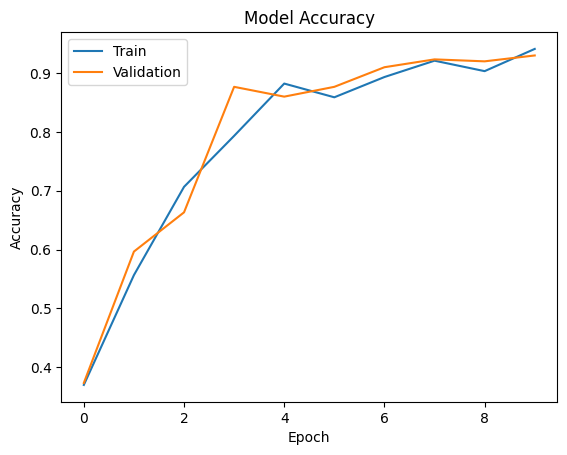

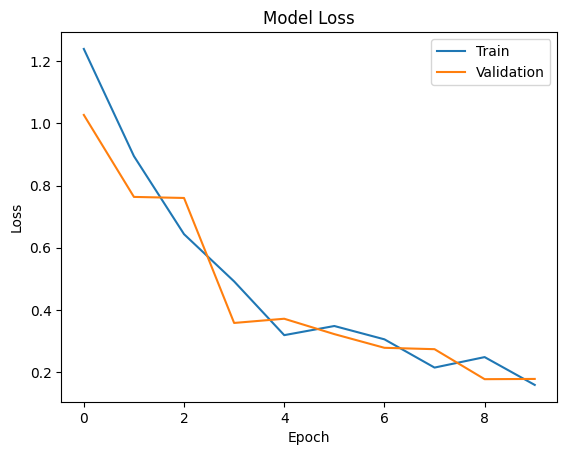

In [16]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])
plt.show()


plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])
plt.show()

Evaluate Model on Test Data

In [17]:
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 385ms/step - accuracy: 0.9700 - loss: 0.1035
Test Accuracy: 0.9700000286102295


Confusion Matrix

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 356ms/step


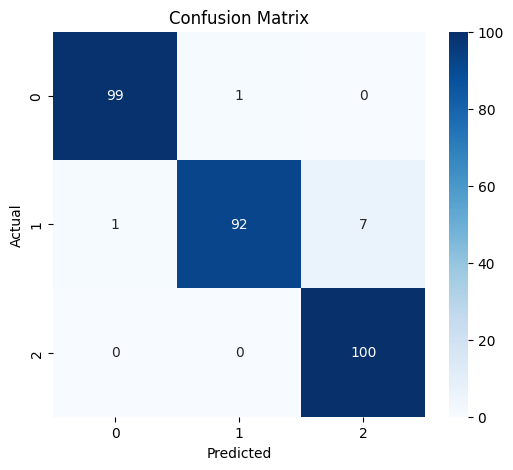

In [18]:
y_pred = model.predict(test_generator)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

cm = confusion_matrix(
    y_true,
    y_pred_classes
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Classification Report

In [19]:
class_names = list(
    test_generator.class_indices.keys()
)

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=class_names
    )
)

                       precision    recall  f1-score   support

Potato___Early_blight       0.99      0.99      0.99       100
 Potato___Late_blight       0.99      0.92      0.95       100
     Potato___healthy       0.93      1.00      0.97       100

             accuracy                           0.97       300
            macro avg       0.97      0.97      0.97       300
         weighted avg       0.97      0.97      0.97       300



Save Model

In [20]:
model.save("potato_disease_model.h5")

print("Model Saved Successfully")

Model Saved Successfully
